# MST Event Boundary Analysis — Memory Metrics & Response Patterns
## REC, LDI, response distributions, and cross-condition comparisons

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import os, re, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
})

BASE = Path(r'E:/Study Sem 6/BRSM')
DATA = BASE / 'MST_Data'
print('Paths configured:', DATA)

Paths configured: E:\Study Sem 6\BRSM\MST_Data


## 1. Data Loading

In [2]:
# ── Preprocessing helpers ──

def load_bin_mapping(filepath):
    mapping = {}
    with open(filepath) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                mapping[int(parts[0])] = int(parts[1])
    return mapping

def extract_item_number(image_path):
    if pd.isna(image_path): return None
    cleaned = str(image_path).replace('\\', '/')
    m = re.search(r'(\d+)', os.path.basename(cleaned))
    return int(m.group(1)) if m else None

def classify_item_type(image_path):
    if pd.isna(image_path): return None
    s = str(image_path).replace('\\', '/')
    if s.lower().startswith('foil'): return 'Foil'
    bn = os.path.basename(s)
    if bn.endswith('a.jpg'): return 'Target'
    elif bn.endswith('b.jpg'): return 'Lure'
    return None

def classify_image_category(image_path):
    if pd.isna(image_path): return None
    s = str(image_path).replace('\\', '/').lower()
    if 'scene' in s: return 'Scene'
    return 'Object'

def map_response(key):
    if pd.isna(key): return None
    k = str(key).strip().lower()
    return {'o': 'Old', 's': 'Similar', 'n': 'New'}.get(k)

def map_position(pos):
    if pd.isna(pos): return None
    p = str(pos).strip().lower()
    return {'pre': 'Pre', 'post': 'Post', 'mid': 'Mid', 'none': 'Foil'}.get(p)

print('Helpers ready.')

Helpers ready.


In [3]:
# ── Load all three conditions ──

CONDITIONS = {
    'Task-Only': (DATA/'task_only'/'task_only_data', DATA/'task_only'/'Set6 bins_ob.txt', None),
    'Both':      (DATA/'Both_item_task'/'both_data', DATA/'Both_item_task'/'Set6 bins.txt',
                  DATA/'Both_item_task'/'SetScC bins.txt'),
    'Item-Only': (DATA/'item_only'/'item_only_data', DATA/'item_only'/'Set6 bins.txt',
                  DATA/'item_only'/'SetScC bins.txt'),
}

def load_condition(data_dir, obj_bin_file, scene_bin_file=None):
    """Load encoding + test data for a single condition."""
    obj_bins = load_bin_mapping(obj_bin_file)
    scene_bins = load_bin_mapping(scene_bin_file) if scene_bin_file else {}

    all_files = sorted(os.listdir(data_dir))
    task_files = [f for f in all_files if '_task_' in f and f.endswith('.csv')]
    test_files = [f for f in all_files if '_test_' in f and f.endswith('.csv')]

    task_by_id = {f[:5]: f for f in task_files}
    test_by_id = {f[:5]: f for f in test_files}
    valid_ids = sorted(set(task_by_id) & set(test_by_id))

    enc_records, test_records = [], []
    for pid in valid_ids:
        # Encoding
        tf = pd.read_csv(data_dir / task_by_id[pid])
        trials = tf[tf['trials.thisN'].notna()].copy()
        if len(trials) == 0: continue
        trials['participant'] = pid
        trials['block'] = trials['trials.thisN'].astype(int) // 7
        trials['pos_in_block'] = trials['trials.thisN'].astype(int) % 7
        trials['boundary_pos'] = trials['pos_in_block'].map(
            lambda p: 'Post' if p == 0 else ('Pre' if p == 6 else 'Mid'))

        def compute_rt(row):
            if pd.notna(row.get('key_resp_9.rt')): return row['key_resp_9.rt'] * 1000
            if pd.notna(row.get('key_resp_8.rt')): return 3000 + row['key_resp_8.rt'] * 1000
            return np.nan
        trials['rt_ms'] = trials.apply(compute_rt, axis=1)

        if 'encoding_task_accuracy' in tf.columns:
            enc_acc = tf['encoding_task_accuracy'].dropna()
            trials['encoding_accuracy'] = enc_acc.iloc[-1] if len(enc_acc) > 0 else np.nan
        else:
            trials['encoding_accuracy'] = np.nan

        enc_records.append(trials[['participant','image_path','block','pos_in_block',
                                   'boundary_pos','rt_ms','encoding_accuracy',
                                   'key_resp_9.keys','key_resp_8.keys']].copy())

        # Test
        testf = pd.read_csv(data_dir / test_by_id[pid])
        ttrials = testf[testf['image_path'].notna()].copy()
        if len(ttrials) == 0: continue
        ttrials['participant'] = pid
        ttrials['item_type'] = ttrials['image_path'].apply(classify_item_type)
        ttrials['position'] = ttrials['position_of_stimuli'].apply(map_position)
        ttrials['response'] = ttrials['key_resp_3.keys'].apply(map_response)
        ttrials['test_rt'] = ttrials['key_resp_3.rt'] * 1000
        ttrials['item_number'] = ttrials['image_path'].apply(extract_item_number)
        ttrials['img_category'] = ttrials['image_path'].apply(classify_image_category)

        def get_bin(row):
            if row['item_type'] != 'Lure': return np.nan
            num = row['item_number']; cat = row['img_category']
            if cat == 'Scene' and num in scene_bins: return scene_bins[num]
            if num in obj_bins: return obj_bins[num]
            return np.nan
        ttrials['lure_bin'] = ttrials.apply(get_bin, axis=1)

        test_records.append(ttrials[['participant','image_path','item_type','position',
                                     'response','test_rt','item_number','img_category',
                                     'lure_bin']].copy())

    enc_df = pd.concat(enc_records, ignore_index=True) if enc_records else pd.DataFrame()
    test_df = pd.concat(test_records, ignore_index=True) if test_records else pd.DataFrame()
    return enc_df, test_df

all_enc, all_test = {}, {}
for cond, (ddir, obj_f, scene_f) in CONDITIONS.items():
    enc, tst = load_condition(ddir, obj_f, scene_f)
    all_enc[cond] = enc
    all_test[cond] = tst
    print(f'{cond}: {enc["participant"].nunique() if len(enc) else 0} participants, '
          f'{len(tst)} test trials')

Task-Only: 53 participants, 7950 test trials
Both: 49 participants, 7350 test trials
Item-Only: 56 participants, 8400 test trials


## 2. REC and LDI Computation

- **REC** (Recognition) = P("Old" | Target) − P("Old" | Foil)
- **LDI** (Lure Discrimination Index) = P("Similar" | Lure) − P("Similar" | Foil)

Both are baseline-corrected against foil response rates.

In [4]:
def compute_rec_ldi(test_df):
    """Compute per-participant REC and LDI for each boundary position."""
    results = []
    for pid in test_df['participant'].unique():
        pdata = test_df[test_df['participant'] == pid]
        foils = pdata[pdata['item_type'] == 'Foil']
        n_foils = len(foils[foils['response'].notna()])
        if n_foils == 0: continue
        p_old_foil = (foils['response'] == 'Old').sum() / n_foils
        p_sim_foil = (foils['response'] == 'Similar').sum() / n_foils

        for pos in ['Pre', 'Mid', 'Post']:
            targets = pdata[(pdata['item_type'] == 'Target') & (pdata['position'] == pos)]
            nt = len(targets[targets['response'].notna()])
            p_old_t = (targets['response'] == 'Old').sum() / nt if nt > 0 else np.nan

            lures = pdata[(pdata['item_type'] == 'Lure') & (pdata['position'] == pos)]
            nl = len(lures[lures['response'].notna()])
            p_sim_l = (lures['response'] == 'Similar').sum() / nl if nl > 0 else np.nan

            results.append({
                'participant': pid, 'position': pos,
                'REC': p_old_t - p_old_foil if not np.isnan(p_old_t) else np.nan,
                'LDI': p_sim_l - p_sim_foil if not np.isnan(p_sim_l) else np.nan,
                'p_old_target': p_old_t, 'p_sim_lure': p_sim_l,
                'p_old_foil': p_old_foil, 'p_sim_foil': p_sim_foil,
            })
    return pd.DataFrame(results)

rec_ldi_all = {}
for cond, test_df in all_test.items():
    rec_ldi_all[cond] = compute_rec_ldi(test_df)
    df = rec_ldi_all[cond]
    print(f'\n=== {cond} ===')
    for pos in ['Pre', 'Mid', 'Post']:
        sub = df[df['position'] == pos]
        print(f"  {pos}: REC M={sub['REC'].mean():.3f} SD={sub['REC'].std():.3f}, "
              f"LDI M={sub['LDI'].mean():.3f} SD={sub['LDI'].std():.3f}")


=== Task-Only ===
  Pre: REC M=0.624 SD=0.195, LDI M=0.387 SD=0.205
  Mid: REC M=0.601 SD=0.183, LDI M=0.369 SD=0.180
  Post: REC M=0.563 SD=0.204, LDI M=0.386 SD=0.229

=== Both ===
  Pre: REC M=0.612 SD=0.153, LDI M=0.261 SD=0.186
  Mid: REC M=0.634 SD=0.171, LDI M=0.292 SD=0.221
  Post: REC M=0.561 SD=0.162, LDI M=0.258 SD=0.188

=== Item-Only ===
  Pre: REC M=0.627 SD=0.157, LDI M=0.314 SD=0.213
  Mid: REC M=0.640 SD=0.178, LDI M=0.330 SD=0.188
  Post: REC M=0.635 SD=0.188, LDI M=0.314 SD=0.172


## 3. Test Phase Response Distributions

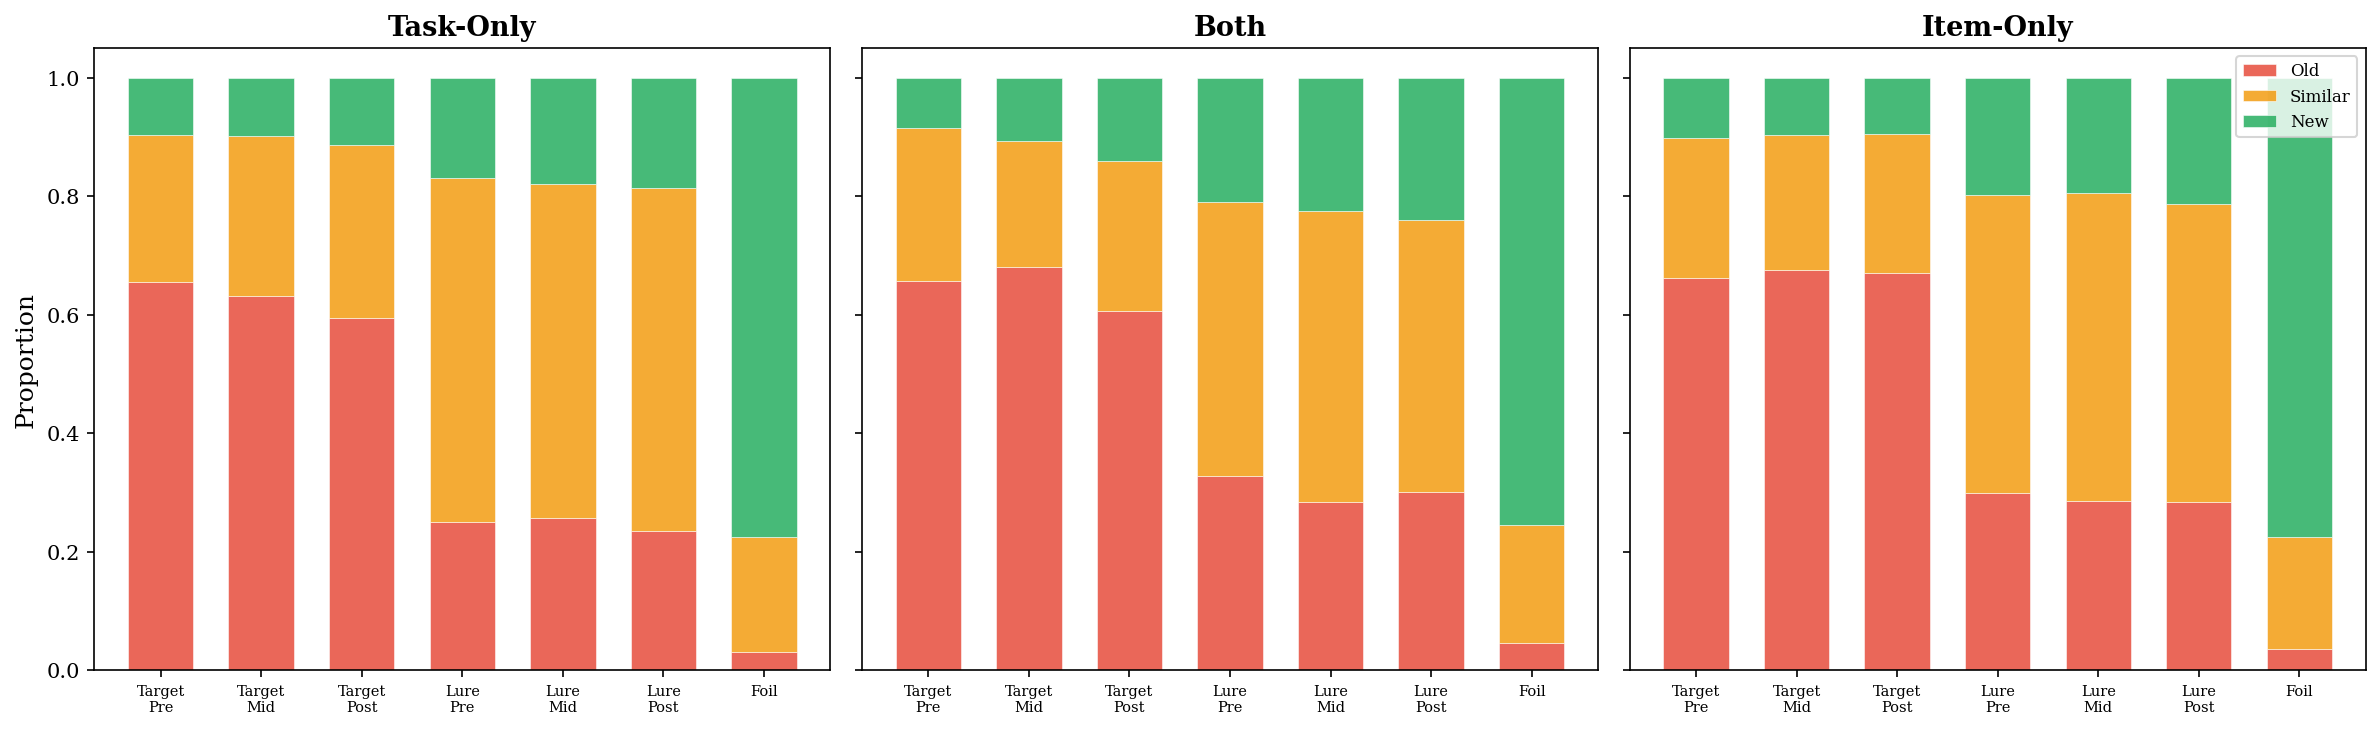

In [5]:
# ── Figure 2: Stacked response distributions per condition ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
resp_order = ['Old', 'Similar', 'New']
resp_colors = {'Old': '#e74c3c', 'Similar': '#f39c12', 'New': '#27ae60'}

raw_resp_all = {}

for idx, (cond, test_df) in enumerate(all_test.items()):
    ax = axes[idx]
    
    item_types = ['Target', 'Lure', 'Foil']
    positions_by_type = {'Target': ['Pre', 'Mid', 'Post'],
                         'Lure': ['Pre', 'Mid', 'Post'],
                         'Foil': ['Foil']}
    
    bar_labels = []
    bar_data = {r: [] for r in resp_order}
    bar_data_sem = {r: [] for r in resp_order}
    
    for it in item_types:
        for pos in positions_by_type[it]:
            label = f"{it}\n{pos}" if pos != 'Foil' else 'Foil'
            bar_labels.append(label)
            
            mask = (test_df['item_type'] == it) & (test_df['position'] == pos)
            sub = test_df[mask].copy()
            
            # Per-participant proportions
            props = []
            for pid in sub['participant'].unique():
                psub = sub[sub['participant'] == pid]
                total = len(psub[psub['response'].notna()])
                if total == 0: continue
                row = {r: (psub['response'] == r).sum() / total for r in resp_order}
                props.append(row)
            
            props_df = pd.DataFrame(props)
            for r in resp_order:
                bar_data[r].append(props_df[r].mean() if len(props_df) > 0 else 0)
                bar_data_sem[r].append(props_df[r].sem() if len(props_df) > 0 else 0)
    
    x = np.arange(len(bar_labels))
    width = 0.65
    bottom = np.zeros(len(bar_labels))
    
    for r in resp_order:
        ax.bar(x, bar_data[r], width, bottom=bottom, label=r,
               color=resp_colors[r], alpha=0.85, edgecolor='white', linewidth=0.3)
        bottom += np.array(bar_data[r])
    
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, fontsize=7)
    ax.set_ylabel('Proportion' if idx == 0 else '')
    ax.set_title(f'{cond}', fontweight='bold')
    ax.set_ylim(0, 1.05)
    if idx == 2:
        ax.legend(loc='upper right', fontsize=8)
    
    raw_resp_all[cond] = {'labels': bar_labels, 'data': bar_data}

plt.tight_layout()
plt.savefig(BASE / 'fig2_response_dist.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig2_response_dist.png', bbox_inches='tight')
plt.show()

## 4. Baseline-Corrected REC and LDI

We subtract the Mid-position value from Post and Pre to get boundary-related change scores,  
then test whether each delta differs from zero.

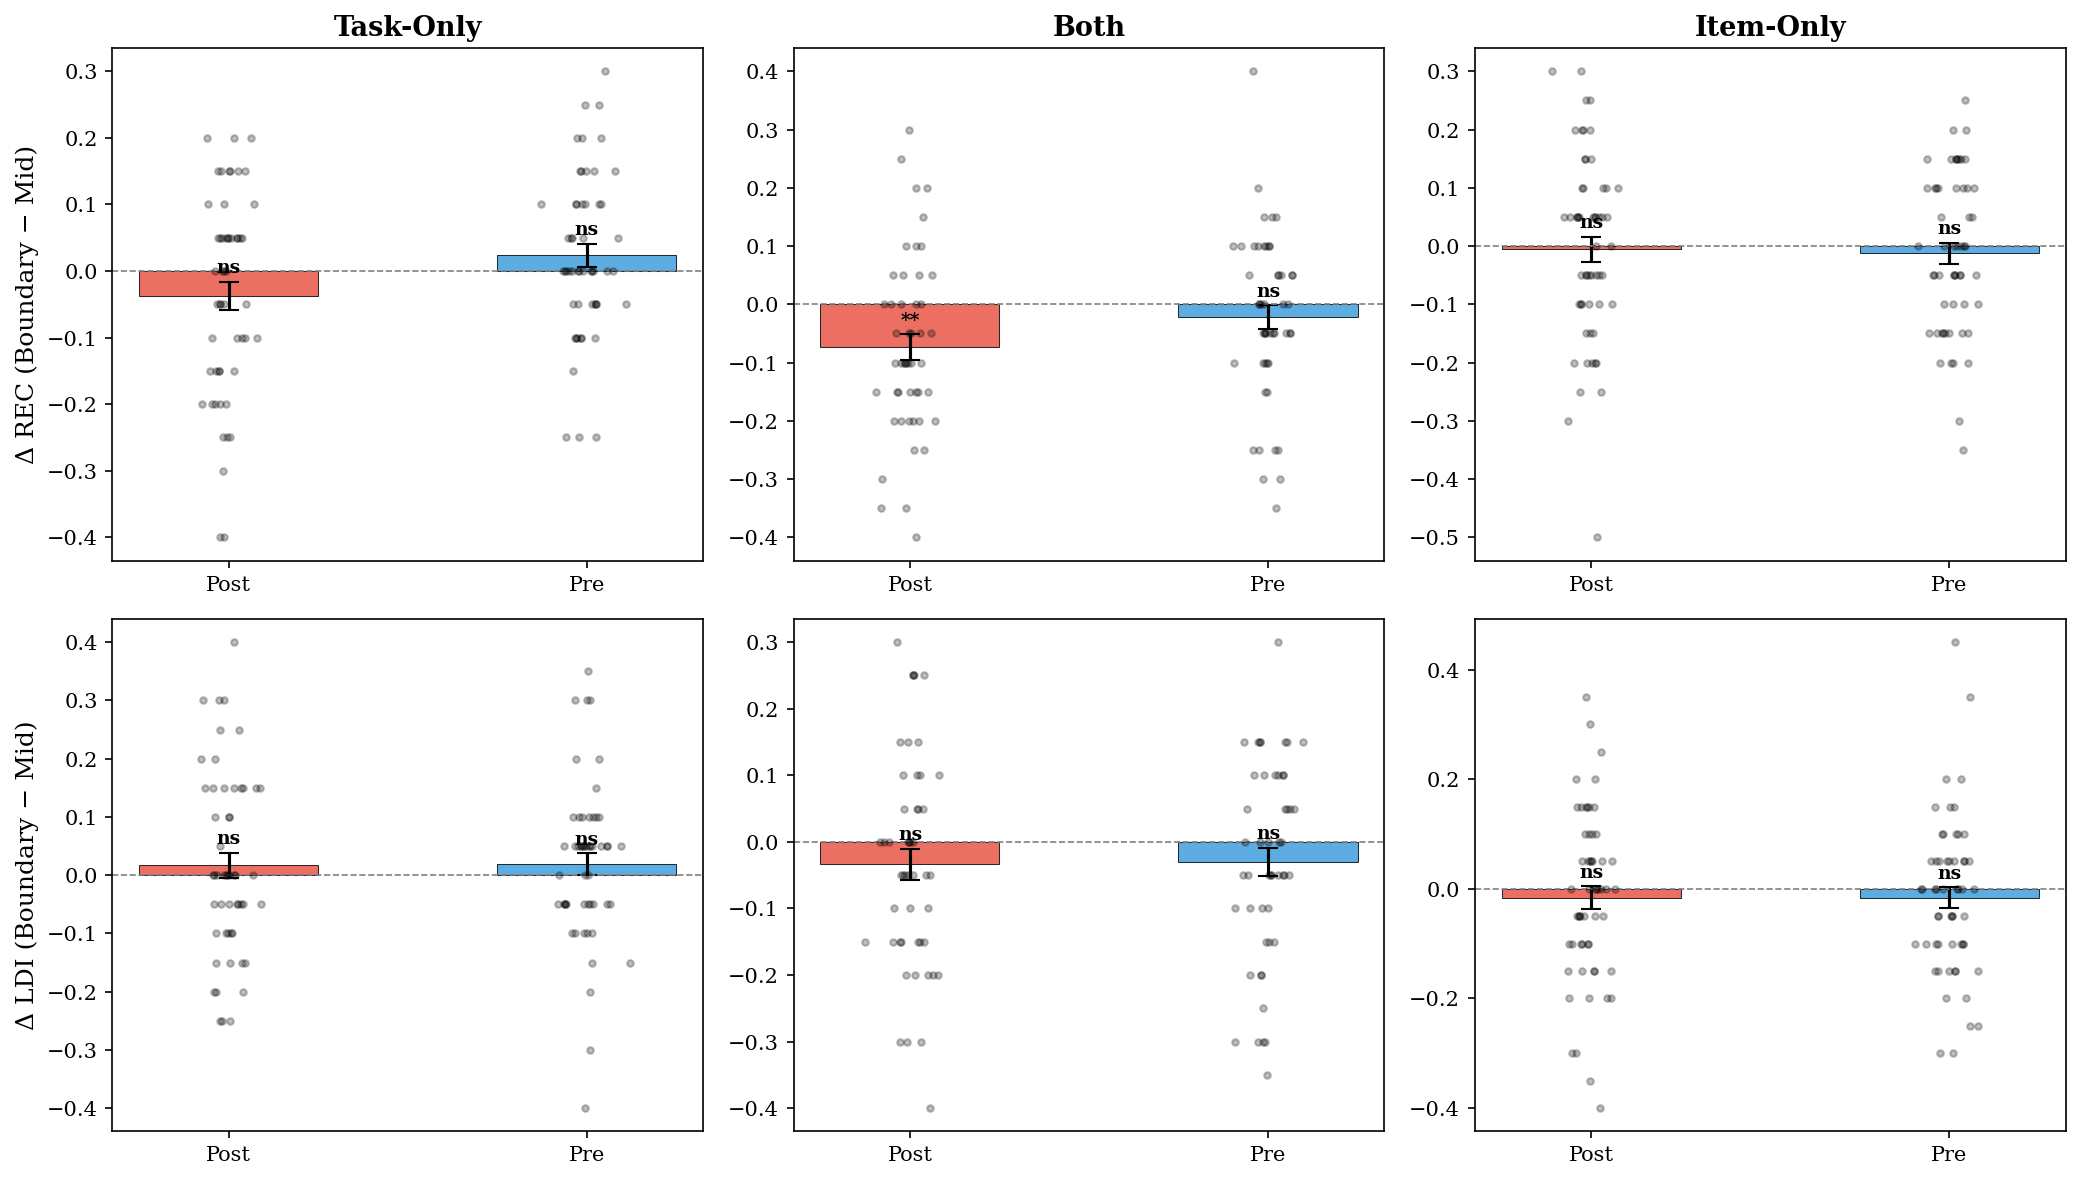


--- Task-Only_REC (N=53) ---
  Post Δ: M=-0.038, SD=0.153, t=-1.801, p=0.0775, d=-0.247
  Pre Δ:  M=0.024, SD=0.123, t=1.395, p=0.1690, d=0.192
  Post vs Pre: t=-2.278, p=0.0248

--- Task-Only_LDI (N=53) ---
  Post Δ: M=0.017, SD=0.158, t=0.782, p=0.4378, d=0.107
  Pre Δ:  M=0.019, SD=0.138, t=0.992, p=0.3256, d=0.136
  Post vs Pre: t=-0.065, p=0.9480

--- Both_REC (N=49) ---
  Post Δ: M=-0.073, SD=0.154, t=-3.336, p=0.0016, d=-0.477
  Pre Δ:  M=-0.022, SD=0.145, t=-1.083, p=0.2842, d=-0.155
  Post vs Pre: t=-1.687, p=0.0948

--- Both_LDI (N=49) ---
  Post Δ: M=-0.034, SD=0.161, t=-1.468, p=0.1485, d=-0.210
  Pre Δ:  M=-0.031, SD=0.149, t=-1.436, p=0.1575, d=-0.205
  Post vs Pre: t=-0.098, p=0.9223

--- Item-Only_REC (N=56) ---
  Post Δ: M=-0.005, SD=0.161, t=-0.249, p=0.8041, d=-0.033
  Pre Δ:  M=-0.012, SD=0.136, t=-0.688, p=0.4942, d=-0.092
  Post vs Pre: t=0.254, p=0.8001

--- Item-Only_LDI (N=56) ---
  Post Δ: M=-0.016, SD=0.156, t=-0.769, p=0.4452, d=-0.103
  Pre Δ:  M=-0.016, S

In [6]:
# ── Figure 3: Baseline-corrected REC and LDI — all conditions ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

stats_results = {}

for col_idx, (cond, df) in enumerate(rec_ldi_all.items()):
    for row_idx, metric in enumerate(['REC', 'LDI']):
        ax = axes[row_idx, col_idx]
        wide = df.pivot(index='participant', columns='position', values=metric)
        
        # Baseline correction: subtract Mid
        delta_pre = wide['Pre'] - wide['Mid']
        delta_post = wide['Post'] - wide['Mid']
        
        positions_plot = ['Post', 'Pre']
        deltas = [delta_post, delta_pre]
        pos_colors = ['#e74c3c', '#3498db']
        
        for i, (pos, delta, c) in enumerate(zip(positions_plot, deltas, pos_colors)):
            m = delta.mean()
            sem = delta.sem()
            ax.bar(i, m, yerr=sem, capsize=5, color=c, alpha=0.8,
                   edgecolor='black', linewidth=0.5, width=0.5)
            jitter = np.random.normal(0, 0.04, size=len(delta))
            ax.scatter([i + j for j in jitter], delta.values, color='black',
                       alpha=0.25, s=10, zorder=5)
        
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Post', 'Pre'])
        
        if col_idx == 0:
            ax.set_ylabel(f'Δ {metric} (Boundary − Mid)')
        if row_idx == 0:
            ax.set_title(f'{cond}', fontweight='bold')
        
        # One-sample t-tests against zero
        t_post, p_post = stats.ttest_1samp(delta_post.dropna(), 0)
        t_pre, p_pre = stats.ttest_1samp(delta_pre.dropna(), 0)
        
        # Cohen's d
        d_post = delta_post.mean() / delta_post.std() if delta_post.std() > 0 else 0
        d_pre = delta_pre.mean() / delta_pre.std() if delta_pre.std() > 0 else 0
        
        # Post vs Pre comparison
        t_pp, p_pp = stats.ttest_ind(delta_post.dropna(), delta_pre.dropna())
        
        # Significance markers
        for i, (p, pos_label) in enumerate([(p_post, 'Post'), (p_pre, 'Pre')]):
            if p < 0.001:   sig = '***'
            elif p < 0.01:  sig = '**'
            elif p < 0.05:  sig = '*'
            else:           sig = 'ns'
            ax.text(i, deltas[i].mean() + deltas[i].sem() + 0.015, sig,
                    ha='center', fontsize=9, fontweight='bold')
        
        stats_key = f'{cond}_{metric}'
        stats_results[stats_key] = {
            'Post_delta_M': delta_post.mean(), 'Post_delta_SD': delta_post.std(),
            'Pre_delta_M': delta_pre.mean(), 'Pre_delta_SD': delta_pre.std(),
            't_post': t_post, 'p_post': p_post, 'd_post': d_post,
            't_pre': t_pre, 'p_pre': p_pre, 'd_pre': d_pre,
            't_post_vs_pre': t_pp, 'p_post_vs_pre': p_pp,
            'N': len(delta_post.dropna()),
        }

plt.tight_layout()
plt.savefig(BASE / 'fig3_rec_ldi.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig3_rec_ldi.png', bbox_inches='tight')
plt.show()

# Print stats
for key, s in stats_results.items():
    print(f"\n--- {key} (N={s['N']}) ---")
    print(f"  Post Δ: M={s['Post_delta_M']:.3f}, SD={s['Post_delta_SD']:.3f}, "
          f"t={s['t_post']:.3f}, p={s['p_post']:.4f}, d={s['d_post']:.3f}")
    print(f"  Pre Δ:  M={s['Pre_delta_M']:.3f}, SD={s['Pre_delta_SD']:.3f}, "
          f"t={s['t_pre']:.3f}, p={s['p_pre']:.4f}, d={s['d_pre']:.3f}")
    print(f"  Post vs Pre: t={s['t_post_vs_pre']:.3f}, p={s['p_post_vs_pre']:.4f}")

## 5. Cross-Condition Comparison

Do boundary effects on REC/LDI differ between Task-Only, Item-Only, and Both conditions?

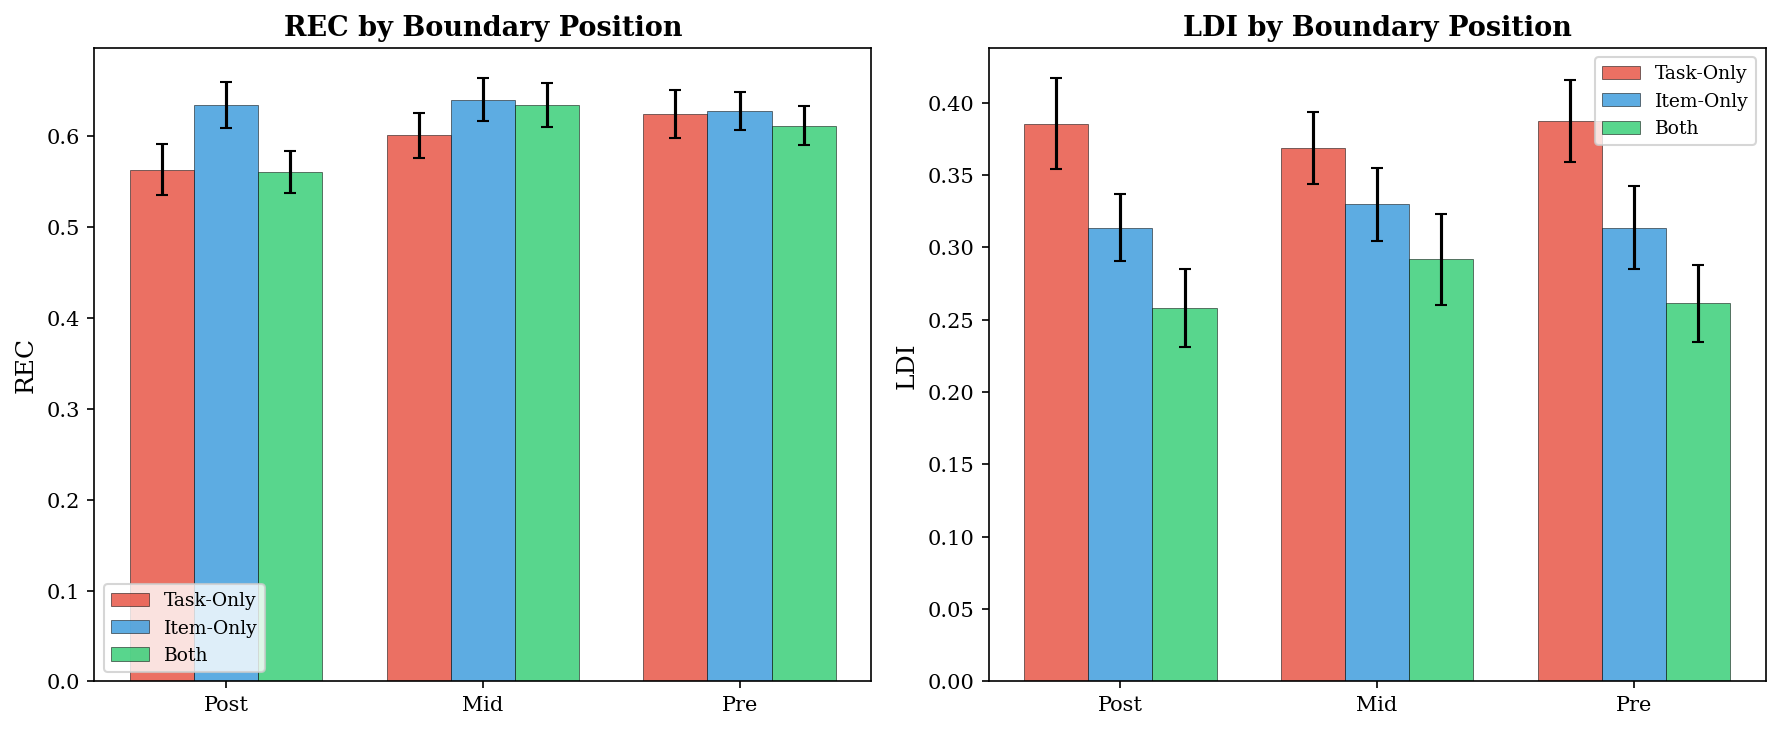


=== Cross-Condition ANOVA on Baseline-Corrected Scores ===
REC Post Δ: F=2.490, p=0.0862
REC Pre Δ: F=1.680, p=0.1898
LDI Post Δ: F=1.359, p=0.2600
LDI Pre Δ: F=1.613, p=0.2025


In [7]:
# ── Figure 7: Cross-condition comparison of REC and LDI ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cond_order = ['Task-Only', 'Item-Only', 'Both']
cond_colors = {'Task-Only': '#e74c3c', 'Item-Only': '#3498db', 'Both': '#2ecc71'}

for metric_idx, metric in enumerate(['REC', 'LDI']):
    ax = axes[metric_idx]
    
    x = np.arange(3)  # Post, Mid, Pre
    width = 0.25
    
    for i, cond in enumerate(cond_order):
        df = rec_ldi_all[cond]
        means = []
        sems = []
        for pos in ['Post', 'Mid', 'Pre']:
            sub = df[df['position'] == pos]
            means.append(sub[metric].mean())
            sems.append(sub[metric].sem())
        
        offset = (i - 1) * width
        ax.bar(x + offset, means, width, yerr=sems, capsize=3,
               color=cond_colors[cond], alpha=0.8, edgecolor='black',
               linewidth=0.3, label=cond)
    
    ax.set_xticks(x)
    ax.set_xticklabels(['Post', 'Mid', 'Pre'])
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Boundary Position', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig(BASE / 'fig7_cross_condition.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig7_cross_condition.png', bbox_inches='tight')
plt.show()

# Cross-condition ANOVA on baseline-corrected scores
print('\n=== Cross-Condition ANOVA on Baseline-Corrected Scores ===')
for metric in ['REC', 'LDI']:
    for pos in ['Post', 'Pre']:
        groups = []
        for cond in cond_order:
            df = rec_ldi_all[cond]
            wide = df.pivot(index='participant', columns='position', values=metric)
            delta = (wide[pos] - wide['Mid']).dropna()
            groups.append(delta.values)
        
        F, p = stats.f_oneway(*groups)
        print(f'{metric} {pos} Δ: F={F:.3f}, p={p:.4f}')

## 6. Response Bias Analysis

Overall proportion of Old/Similar/New responses per condition, regardless of item type.

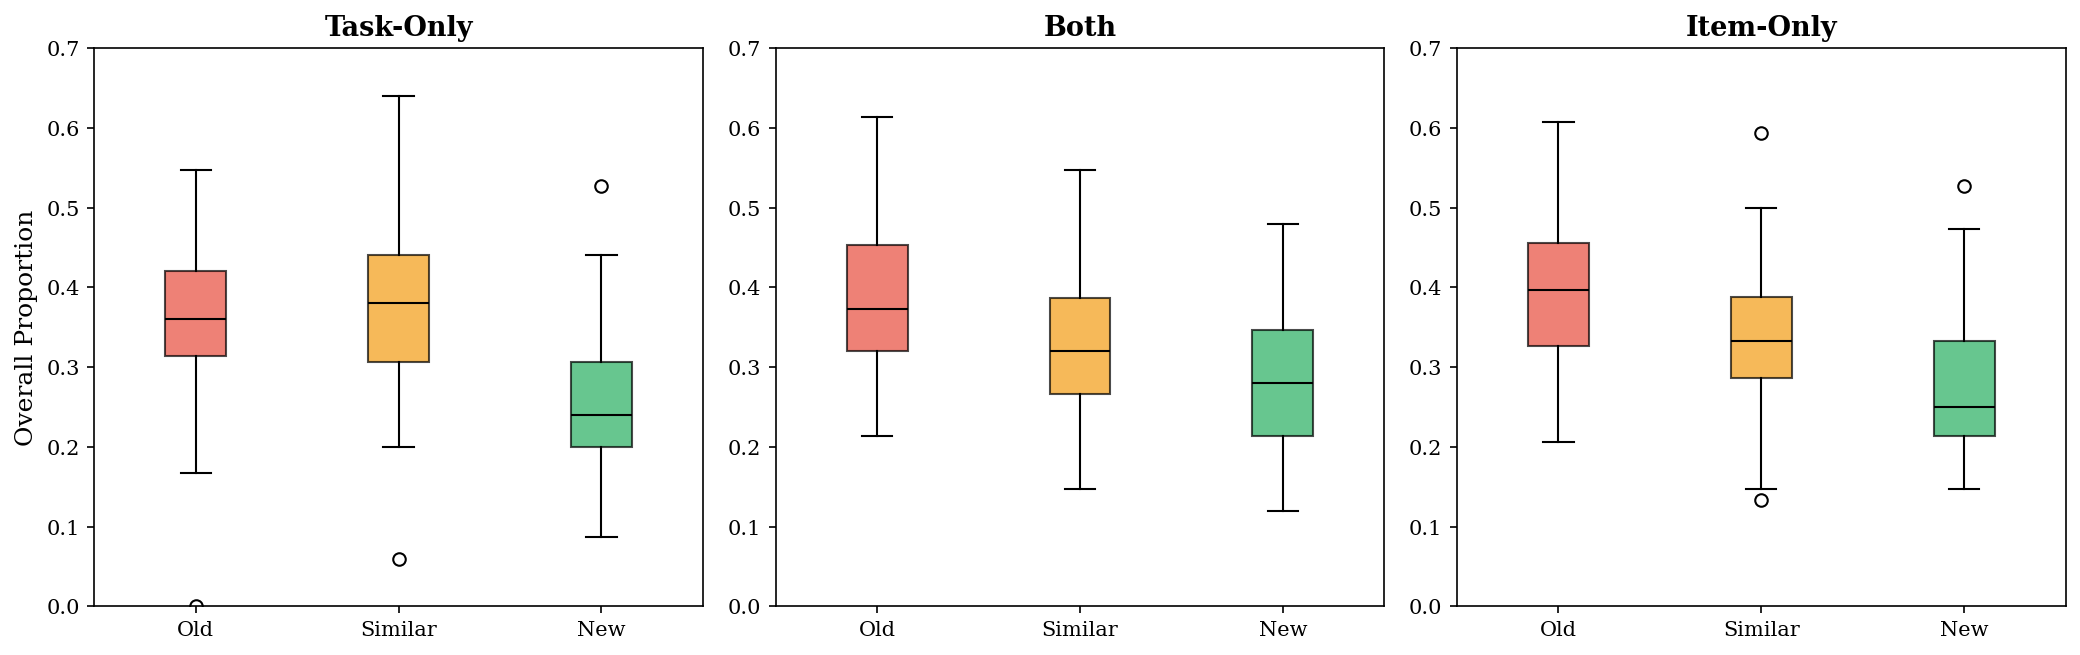

In [8]:
# ── Figure 9: Response bias (overall proportion of each response type) ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for idx, (cond, test_df) in enumerate(all_test.items()):
    ax = axes[idx]
    
    bias_data = []
    for pid in test_df['participant'].unique():
        pdata = test_df[test_df['participant'] == pid]
        valid = pdata[pdata['response'].notna()]
        total = len(valid)
        if total == 0: continue
        bias_data.append({
            'participant': pid,
            'P(Old)': (valid['response'] == 'Old').sum() / total,
            'P(Similar)': (valid['response'] == 'Similar').sum() / total,
            'P(New)': (valid['response'] == 'New').sum() / total,
        })
    
    bias_df = pd.DataFrame(bias_data)
    
    bp = ax.boxplot([bias_df['P(Old)'], bias_df['P(Similar)'], bias_df['P(New)']],
                     labels=['Old', 'Similar', 'New'],
                     patch_artist=True,
                     boxprops=dict(alpha=0.7),
                     medianprops=dict(color='black'))
    
    colors_box = ['#e74c3c', '#f39c12', '#27ae60']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
    
    ax.set_ylabel('Overall Proportion' if idx == 0 else '')
    ax.set_title(f'{cond}', fontweight='bold')
    ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.savefig(BASE / 'fig9_response_bias.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig9_response_bias.png', bbox_inches='tight')
plt.show()

## 7. Individual Differences: REC vs LDI Scatter

Are recognition memory (REC) and lure discrimination (LDI) correlated across participants?

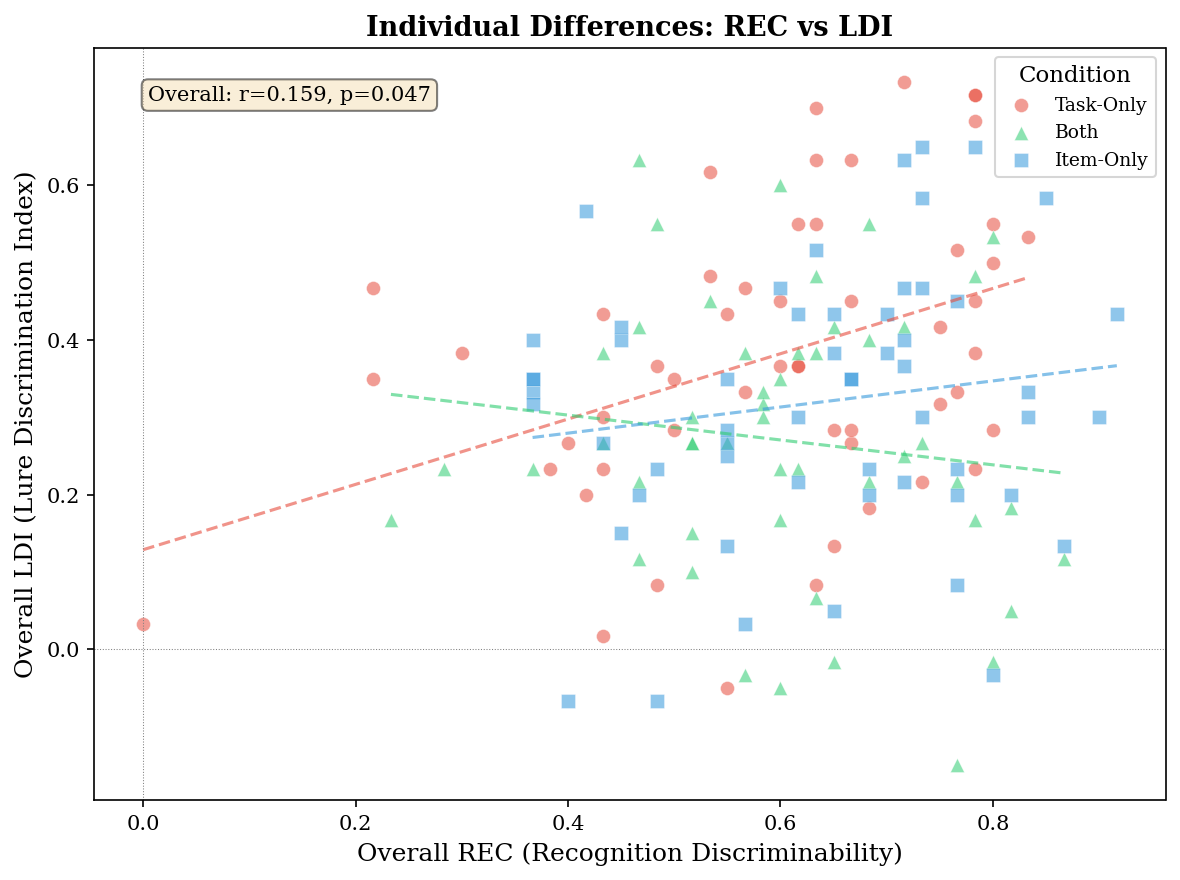

In [9]:
# ── Figure 12: Individual differences — REC vs LDI scatter ──
fig, ax = plt.subplots(figsize=(8, 6))
cond_colors_s = {'Task-Only': '#e74c3c', 'Item-Only': '#3498db', 'Both': '#2ecc71'}
cond_markers_s = {'Task-Only': 'o', 'Item-Only': 's', 'Both': '^'}

for cond, df in rec_ldi_all.items():
    overall = df.groupby('participant')[['REC', 'LDI']].mean().dropna()
    ax.scatter(overall['REC'], overall['LDI'], alpha=0.55, s=45,
              color=cond_colors_s[cond], marker=cond_markers_s[cond],
              label=cond, edgecolors='white', linewidth=0.3)
    # Per-condition regression line
    if len(overall) > 2:
        slope, intercept, r, p, se = stats.linregress(overall['REC'], overall['LDI'])
        xl = np.linspace(overall['REC'].min(), overall['REC'].max(), 100)
        ax.plot(xl, slope*xl + intercept, color=cond_colors_s[cond],
                linewidth=1.5, alpha=0.6, linestyle='--')

# Overall correlation
all_rl = pd.concat([df.groupby('participant')[['REC','LDI']].mean()
                     for df in rec_ldi_all.values()])
all_valid = all_rl.dropna()
if len(all_valid) > 2:
    r_all, p_all = stats.pearsonr(all_valid['REC'], all_valid['LDI'])
    ax.text(0.05, 0.95, f'Overall: r={r_all:.3f}, p={p_all:.3f}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Overall REC (Recognition Discriminability)')
ax.set_ylabel('Overall LDI (Lure Discrimination Index)')
ax.set_title('Individual Differences: REC vs LDI', fontweight='bold')
ax.legend(title='Condition', fontsize=9)
ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.savefig(BASE / 'fig12_rec_ldi_scatter.pdf', bbox_inches='tight')
plt.savefig(BASE / 'fig12_rec_ldi_scatter.png', bbox_inches='tight')
plt.show()

## 8. Memory Metrics — Summary for Report

In [10]:
print('=' * 70)
print('MEMORY METRICS SUMMARY')
print('=' * 70)

for cond in ['Task-Only', 'Both', 'Item-Only']:
    rl = rec_ldi_all[cond]
    N = rl['participant'].nunique()
    print(f'\n{"="*45}')
    print(f'CONDITION: {cond} (N={N})')
    print(f'{"="*45}')

    # Raw REC & LDI
    for metric in ['REC', 'LDI']:
        wide = rl.pivot(index='participant', columns='position', values=metric).dropna()
        print(f'\n{metric}:')
        for pos in ['Pre', 'Mid', 'Post']:
            print(f'  {pos}: M={wide[pos].mean():.3f}, SD={wide[pos].std():.3f}')

    # Baseline-corrected
    print('\nBaseline-Corrected:')
    for metric in ['REC', 'LDI']:
        wide = rl.pivot(index='participant', columns='position', values=metric).dropna()
        for pos in ['Post', 'Pre']:
            delta = (wide[pos] - wide['Mid'])
            t, p = stats.ttest_1samp(delta, 0)
            d = delta.mean() / delta.std()
            print(f'  {metric} {pos} Δ: M={delta.mean():.3f}, SD={delta.std():.3f}, '
                  f't({len(delta)-1})={t:.3f}, p={p:.4f}, d={d:.3f}')

MEMORY METRICS SUMMARY

CONDITION: Task-Only (N=53)

REC:
  Pre: M=0.624, SD=0.195
  Mid: M=0.601, SD=0.183
  Post: M=0.563, SD=0.204

LDI:
  Pre: M=0.387, SD=0.205
  Mid: M=0.369, SD=0.180
  Post: M=0.386, SD=0.229

Baseline-Corrected:
  REC Post Δ: M=-0.038, SD=0.153, t(52)=-1.801, p=0.0775, d=-0.247
  REC Pre Δ: M=0.024, SD=0.123, t(52)=1.395, p=0.1690, d=0.192
  LDI Post Δ: M=0.017, SD=0.158, t(52)=0.782, p=0.4378, d=0.107
  LDI Pre Δ: M=0.019, SD=0.138, t(52)=0.992, p=0.3256, d=0.136

CONDITION: Both (N=49)

REC:
  Pre: M=0.612, SD=0.153
  Mid: M=0.634, SD=0.171
  Post: M=0.561, SD=0.162

LDI:
  Pre: M=0.261, SD=0.186
  Mid: M=0.292, SD=0.221
  Post: M=0.258, SD=0.188

Baseline-Corrected:
  REC Post Δ: M=-0.073, SD=0.154, t(48)=-3.336, p=0.0016, d=-0.477
  REC Pre Δ: M=-0.022, SD=0.145, t(48)=-1.083, p=0.2842, d=-0.155
  LDI Post Δ: M=-0.034, SD=0.161, t(48)=-1.468, p=0.1485, d=-0.210
  LDI Pre Δ: M=-0.031, SD=0.149, t(48)=-1.436, p=0.1575, d=-0.205

CONDITION: Item-Only (N=56)

R